# Fixing Assumption Violations — what to actually do about each one

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · **▶ 06 Regression** · 07 Model Prep · 08 Case Studies · 09 Deployment

`06_Statistics_and_Regression/04_fixing_assumption_violations.ipynb`

---

### In one paragraph (no jargon)

Diagnosing a violation is half the work; this notebook is the other half. For each of the six assumptions there is a standard remedy, and applying it correctly — then **re-checking** — is what separates a complete answer from a partial one. Polynomial terms for curvature, robust standard errors for unequal spread, studentised residuals for outliers, VIF-driven pruning for multicollinearity.

### After this notebook you can

- Fix non-linearity with polynomial and log terms, and confirm it worked
- Use HC3 robust standard errors and weighted least squares for heteroscedasticity
- Identify and handle influential outliers with studentised residuals and Cook's distance
- Reduce multicollinearity using VIF, and re-check every fix rather than assuming it worked


### What's inside

1. Setup and baseline model
2. Fixing non-linearity
3. Fixing residual mean
4. Fixing heteroscedasticity
5. Fixing non-normal residuals
6. Addressing autocorrelation
7. Fixing multicollinearity
8. ⚡ Cook's distance — which rows are actually driving the model
9. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Dependent variable (y)** | The thing you're trying to predict or explain. Sales, price, mpg. |
| **Independent variable (X)** | The things you're using to predict it. Also called features or predictors. |
| **Coefficient** | "If this predictor goes up by 1, y changes by this much, holding everything else fixed." |
| **Intercept** | The predicted y when every predictor is zero. Often not meaningful on its own. |
| **Residual** | Actual minus predicted. The bit the model got wrong, for one row. |
| **R²** | The share of the variation in y the model explains. 0 = none, 1 = all. |
| **p-value** | "If this predictor really had no effect, how likely is a result this strong by chance?" Below 0.05 is the usual threshold for taking it seriously. |
| **Homoscedasticity** | The errors are equally spread across the whole range. The opposite is heteroscedasticity. |
| **Autocorrelation** | Today's error is related to yesterday's — common in time series, a problem for the standard formulas. |
| **Multicollinearity** | Two predictors carry nearly the same information, so the model can't tell which deserves the credit. |
| **VIF** | Variance Inflation Factor — the standard multicollinearity score. Above 5 is a warning; above 10 is a problem. |
| **OLS** | Ordinary Least Squares — the standard way of fitting a straight line by minimising squared errors. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
sns.set_theme(style="whitegrid")


def load_mpg():
    """Load seaborn's `mpg` dataset, or build an equivalent if there's no internet.

    WHY: sns.load_dataset() downloads from the web. In a lab with no connection that
    fails, so we fall back to a generated dataset with the SAME columns and the same
    built-in problems (curvature, unequal error spread) that the assumption checks
    below are designed to reveal.
    """
    try:
        frame = sns.load_dataset('mpg').dropna()
        print(f"Loaded seaborn's mpg dataset: {frame.shape[0]} rows")
        return frame
    except Exception:
        pass

    print("No internet for sns.load_dataset - generating an equivalent mpg dataset.")
    rng = np.random.default_rng(42)
    n = 392
    cylinders = rng.choice([4, 6, 8], n, p=[.5, .22, .28])
    displacement = cylinders * rng.normal(40, 7, n).clip(20, 70)
    weight = 1200 + displacement * 8 + rng.normal(0, 350, n)
    horsepower = 20 + displacement * 0.55 + rng.normal(0, 12, n)
    acceleration = 22 - horsepower * 0.05 + rng.normal(0, 1.6, n)
    model_year = rng.integers(70, 83, n)
    # mpg falls off NON-LINEARLY with weight (so the linearity check has something to find)
    # and the noise grows with mpg (so the homoscedasticity check has something to find)
    base = 62 - 0.0000042 * weight ** 2 + 0.35 * (model_year - 70)
    mpg = base + rng.normal(0, 1 + base * 0.06, n)
    return pd.DataFrame({
        'mpg': mpg.clip(9, 47).round(1),
        'cylinders': cylinders,
        'displacement': displacement.round(1),
        'horsepower': horsepower.clip(46, 230).round(1),
        'weight': weight.clip(1613, 5140).round(0),
        'acceleration': acceleration.clip(8, 25).round(1),
        'model_year': model_year,
        'origin': rng.choice(['usa', 'japan', 'europe'], n, p=[.62, .2, .18]),
        'name': [f'car_{i}' for i in range(n)],
    })

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Linear Regression Assumptions — **FIXES** (Seaborn `mpg` dataset)

This notebook **addresses** assumption violations and re-checks the model after fixes.

Fixes include:
- Nonlinearity → polynomial terms / log transforms
- Mean residual ≠ 0 → ensure intercept, examine omitted variables
- Heteroscedasticity → robust SE (HC3) and Weighted Least Squares (WLS)
- Non-normality → outlier removal by studentized residuals (>|3|)
- Autocorrelation → HAC (Newey–West) SE (illustration on cross-section)
- Multicollinearity → dropping a redundant predictor / PCA

## 0. Setup & Refit Baseline

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns  # only to load dataset
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load and prepare data
df = load_mpg().dropna().copy()
df['origin'] = df['origin'].astype('category')

X = df[['cylinders','displacement','horsepower','weight','acceleration','model_year']].copy()
X = pd.concat([X, pd.get_dummies(df['origin'], prefix='origin', drop_first=True)], axis=1)
y = df['mpg'].astype(float)
# statsmodels needs every column to be a real number. pd.get_dummies now returns
# True/False, and mixing those with floats gives an 'object' column that OLS rejects.
# One line converts everything to float and the problem disappears.
X = X.astype(float)
Xc = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
print(ols.summary().tables[0])

Loaded seaborn's mpg dataset: 392 rows
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          1.79e-139
Time:                        07:43:23   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         


### 1) Fixing **Nonlinearity**
**Approach:** Add polynomial terms for `horsepower` and `weight`, and log-transform `weight` & `displacement` (positive vars). Refit and compare.

In [3]:
X_fix = X.copy()
# Polynomials
X_fix['horsepower_sq'] = X['horsepower']**2
X_fix['weight_sq'] = X['weight']**2
# Logs (avoid log(0))
for col in ['weight','displacement']:
    X_fix[f'log_{col}'] = np.log(X[col])

Xc_fix = sm.add_constant(X_fix)
ols_poly = sm.OLS(y, Xc_fix).fit()
print(ols_poly.summary().tables[0])

# Ramsey RESET after adding nonlinear terms
from statsmodels.stats.diagnostic import linear_reset
reset = linear_reset(ols_poly, power=2, use_f=True)
print("RESET after nonlinear terms: F=%.3f, p=%.5f" % (reset.fvalue, reset.pvalue))

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     203.8
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          5.54e-157
Time:                        07:43:23   Log-Likelihood:                -967.55
No. Observations:                 392   AIC:                             1961.
Df Residuals:                     379   BIC:                             2013.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
RESET after nonlinear terms: F=29.448, p=0.00000


### 2) Fixing **Mean of Residuals ≠ 0**
**Approach:** Ensure intercept and verify centering. (OLS with a constant guarantees residual mean ≈ 0.)

In [4]:
resid_poly = ols_poly.resid
print("Residual mean (with intercept):", resid_poly.mean())

Residual mean (with intercept): 9.375468564763762e-10


### 3) Fixing **Heteroscedasticity**
**Approach A:** Use **robust standard errors (HC3)**.  
**Approach B:** Fit **Weighted Least Squares (WLS)** where weights ∝ 1 / fitted^2.

In [5]:
# Robust SE (HC3)
robust_poly = ols_poly.get_robustcov_results(cov_type='HC3')
print(robust_poly.summary().tables[0])

# Weighted Least Squares (ad-hoc weights on fitted variance)
fitted_poly = ols_poly.fittedvalues
weights = 1.0 / (fitted_poly**2 + 1e-6)
wls = sm.WLS(y, Xc_fix, weights=weights).fit()
print(wls.summary().tables[0])

# Breusch–Pagan on WLS residuals
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(wls.resid, Xc_fix)
print("Breusch–Pagan (WLS): stat=%.3f, p=%.5f" % (bp_stat, bp_p))

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     48.89
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           6.68e-66
Time:                        07:43:23   Log-Likelihood:                -967.55
No. Observations:                 392   AIC:                             1961.
Df Residuals:                     379   BIC:                             2013.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                            WLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.885
Model:                            WLS   Adj. R-squar

### 4) Fixing **Non-normal residuals**
**Approach:** Remove extreme outliers using **studentized residuals** (>|3|), refit, and re-check normality.

<Figure size 500x400 with 0 Axes>

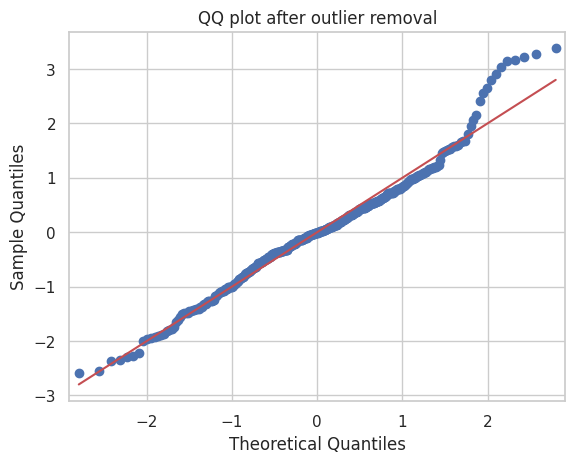

Jarque–Bera p after outlier removal: 0.0


In [6]:
infl = OLSInfluence(ols_poly)
stud_resid = infl.resid_studentized_internal
mask = np.abs(stud_resid) <= 3.0
X_nn = X_fix[mask]
y_nn = y[mask]

ols_nn = sm.OLS(y_nn, sm.add_constant(X_nn)).fit()
from statsmodels.graphics.gofplots import qqplot
fig = plt.figure(figsize=(5,4))
qqplot(ols_nn.resid, line='s', fit=True)
plt.title('QQ plot after outlier removal')
plt.show()

import statsmodels.stats.api as sms
jb_p = sms.jarque_bera(ols_nn.resid)[1]
print("Jarque–Bera p after outlier removal:", round(jb_p,5))

### 5) Addressing **Autocorrelation** (illustrative)

This is cross-sectional data, so strong autocorrelation is unlikely. If present, you can use **HAC (Newey–West)** standard errors:

In [7]:
hac = ols_nn.get_robustcov_results(cov_type='HAC', maxlags=1)
print(hac.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     52.61
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           3.65e-69
Time:                        07:43:23   Log-Likelihood:                -930.28
No. Observations:                 388   AIC:                             1887.
Df Residuals:                     375   BIC:                             1938.
Df Model:                          12                                         
Covariance Type:                  HAC                                         


### 6) Fixing **Multicollinearity**
**Approach A:** Drop a redundant predictor (e.g., `displacement` highly overlaps with `weight`).  
**Approach B:** **PCA** on correlated blocks to create orthogonal components.

In [8]:
# --- A) Drop a redundant predictor ---
X_drop = X_nn.drop(columns=['displacement'])
ols_drop = sm.OLS(y_nn, sm.add_constant(X_drop)).fit()
# Compute VIF
Xc_drop = sm.add_constant(X_drop)
vif_drop = pd.DataFrame({
    'feature': ['const'] + X_drop.columns.tolist(),
    'VIF': [variance_inflation_factor(Xc_drop.values, i) for i in range(Xc_drop.shape[1])]
})
print(vif_drop)

# --- B) PCA on numeric subset (standardize first) ---
num_cols = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
scaler = StandardScaler()
Z = scaler.fit_transform(X_nn[num_cols])
pca = PCA(n_components=3, random_state=0)
PC = pca.fit_transform(Z)
PC_df = pd.DataFrame(PC, columns=['PC1','PC2','PC3'], index=X_nn.index)

X_pca = pd.concat([PC_df, X_nn[[c for c in X_nn.columns if c.startswith('origin_')]]], axis=1)
ols_pca = sm.OLS(y_nn, sm.add_constant(X_pca)).fit()

print("Explained variance ratio (3 PCs):", np.round(pca.explained_variance_ratio_,3))
print(ols_pca.summary().tables[0])

             feature           VIF
0              const  1.361341e+06
1          cylinders  1.501078e+01
2         horsepower  1.077249e+02
3             weight  1.034268e+04
4       acceleration  3.474424e+00
5         model_year  1.350079e+00
6       origin_japan  1.922206e+00
7         origin_usa  3.202275e+00
8      horsepower_sq  6.794925e+01
9          weight_sq  2.673769e+03
10        log_weight  2.558269e+03
11  log_displacement  3.129334e+01
Explained variance ratio (3 PCs): [0.71  0.139 0.113]
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     327.7
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          1.02e-135
Time:                        07:43:24   Log-Likelihood:                -1016.3
No. Observations:

## Final Notes

- After each fix, **re-run the assumption checks** (as in Notebook 1) to validate improvements.
- Choose the simplest model that satisfies assumptions and explains the data well.

### ⚡ Beyond the syllabus — Cook's distance — which individual rows are steering your model

Studentised residuals find points the model predicts badly. **Cook's distance** finds something more useful: points whose *removal would visibly change the fitted line*. A row can have a modest residual and still dominate the model if it sits far out along the x axis. This is the tool for answering "is this result driven by three unusual records?" — a question worth asking of any regression before you present it.

Loaded seaborn's mpg dataset: 392 rows
Rows: 392   Cook's distance threshold (4/n): 0.01020
Rows exceeding it: 28

The five most influential rows:


,cooks_d,leverage,studentised_resid,weight,mpg
394,0.0784,0.0438,2.9261,2130,44.0
326,0.0734,0.0276,3.5946,2335,43.4
13,0.0446,0.1205,-1.2760,3086,14.0
325,0.0393,0.0167,3.3988,2085,44.3
244,0.0345,0.0156,3.2955,1985,43.1


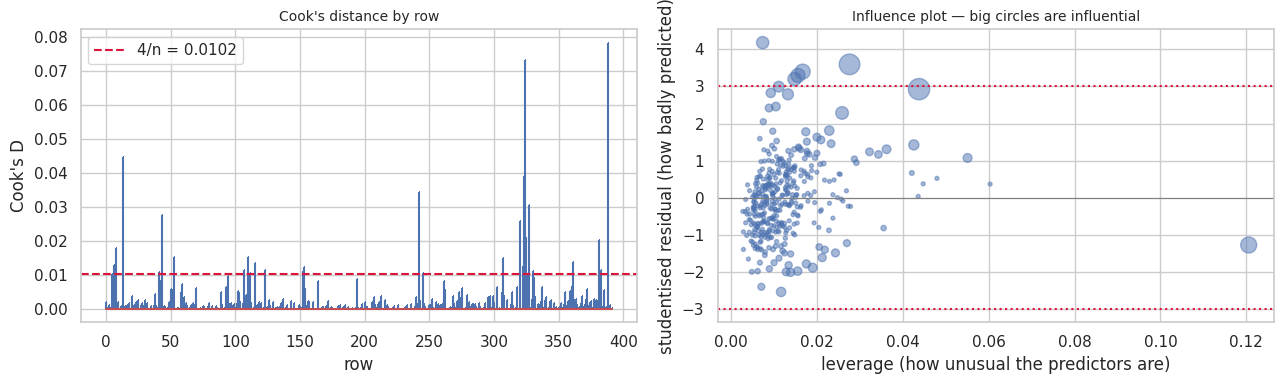


Coefficients before and after removing the influential rows:


,with all rows,influential rows removed,% change
const,-15.3889,-7.7843,-49.4
weight,-0.0066,-0.0063,-5.4
horsepower,0.0026,-0.0101,-485.4
model_year,0.7511,0.6818,-9.2
acceleration,0.0802,-0.0723,-190.2



R²: 0.8086 -> 0.8599

HOW TO DECIDE
  Coefficients barely move  ->  the result is robust. Say so; that's a strength.
  Coefficients move a lot   ->  a handful of rows are driving your conclusion. Investigate
                                them individually. Are they errors, or the most interesting
                                records in the file? Report the finding either way.
  NEVER delete influential points just to improve the fit. Removing a row because it is
  wrong is cleaning; removing it because it is inconvenient is not.


In [9]:
from statsmodels.stats.outliers_influence import OLSInfluence

mpg_df = load_mpg().dropna()
X_c = sm.add_constant(mpg_df[['weight', 'horsepower', 'model_year', 'acceleration']])
y_c = mpg_df['mpg']
fit = sm.OLS(y_c, X_c).fit()

influence = OLSInfluence(fit)
cooks = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
student = influence.resid_studentized_internal

# Conventional threshold: 4/n. Anything above deserves a look.
threshold = 4 / len(mpg_df)
flagged = np.where(cooks > threshold)[0]

print(f"Rows: {len(mpg_df)}   Cook's distance threshold (4/n): {threshold:.5f}")
print(f"Rows exceeding it: {len(flagged)}\n")
print("The five most influential rows:")
top = pd.DataFrame({
    'cooks_d':   cooks,
    'leverage':  leverage,
    'studentised_resid': student,
    'weight':    mpg_df['weight'].values,
    'mpg':       mpg_df['mpg'].values,
}).nlargest(5, 'cooks_d').round(4)
display(top)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(cooks, markerfmt=',')
axes[0].axhline(threshold, color='crimson', ls='--', label=f'4/n = {threshold:.4f}')
axes[0].set_title("Cook's distance by row", fontsize=10)
axes[0].set_xlabel('row'); axes[0].set_ylabel("Cook's D"); axes[0].legend()

axes[1].scatter(leverage, student, s=np.clip(cooks * 3000, 8, 300), alpha=.5)
axes[1].axhline(0, color='grey', lw=.8)
axes[1].axhline(3, color='crimson', ls=':'); axes[1].axhline(-3, color='crimson', ls=':')
axes[1].set_xlabel('leverage (how unusual the predictors are)')
axes[1].set_ylabel('studentised residual (how badly predicted)')
axes[1].set_title('Influence plot — big circles are influential', fontsize=10)
plt.tight_layout(); plt.show()

# Does removing them actually change anything? Measure it rather than assuming.
keep = np.setdiff1d(np.arange(len(mpg_df)), flagged)
refit = sm.OLS(y_c.iloc[keep], X_c.iloc[keep]).fit()
comparison = pd.DataFrame({'with all rows': fit.params, 'influential rows removed': refit.params})
comparison['% change'] = ((comparison.iloc[:, 1] / comparison.iloc[:, 0] - 1) * 100).round(1)
print("\nCoefficients before and after removing the influential rows:")
display(comparison.round(4))
print(f"\nR²: {fit.rsquared:.4f} -> {refit.rsquared:.4f}")

print("""
HOW TO DECIDE
  Coefficients barely move  ->  the result is robust. Say so; that's a strength.
  Coefficients move a lot   ->  a handful of rows are driving your conclusion. Investigate
                                them individually. Are they errors, or the most interesting
                                records in the file? Report the finding either way.
  NEVER delete influential points just to improve the fit. Removing a row because it is
  wrong is cleaning; removing it because it is inconvenient is not.""")

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Add a constant | `sm.add_constant(X)` |
| Fit OLS | `sm.OLS(y, Xc).fit()` |
| Polynomial term | `X['hp_sq'] = X['horsepower']**2` |
| Log term | `X['log_w'] = np.log(X['weight'])` |
| Robust standard errors | `fit.get_robustcov_results(cov_type='HC3')` |
| Weighted least squares | `sm.WLS(y, Xc, weights=w).fit()` |
| Studentised residuals | `OLSInfluence(fit).resid_studentized_internal` |
| Cook's distance | `OLSInfluence(fit).cooks_distance[0]` |
| Newey-West SEs | `fit.get_robustcov_results('HAC', maxlags=1)` |
| VIF | `variance_inflation_factor(Xc.values, i)` |
| Compare models | `fit.rsquared_adj`, `fit.aic`, `fit.bic` |

### Adapting this in the exam

- 'The residual plot shows a funnel — what would you do?' → HC3 robust standard errors, or transform y. Say which and why.
- 'VIF is 12 for two predictors' → they're near-duplicates. Drop one, combine them, or use ridge.
- 'How would you fix non-linearity?' → transform the predictor or add a polynomial term, then show the residual plot again.
- Every fix needs a re-check. 'I applied X and the residual plot now shows no pattern' is the complete answer.

### Traps that cost marks

- Adding polynomial terms raises R² automatically. Use **adjusted** R², AIC or BIC to judge whether the extra term earned its place.
- Robust standard errors fix the p-values, not the coefficients. If the model is misspecified, HC3 won't save it.
- Removing outliers changes the population you're describing. Report how many you removed and why.
- Log-transforming y changes what the coefficients mean and makes R² incomparable with the untransformed model.
- Dropping a collinear predictor changes the interpretation of the ones that remain.
- Fix one thing at a time and re-check. Several simultaneous changes make it impossible to say what helped.